In [1]:
!pip install scikit-learn pandas numpy matplotlib seaborn joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve)
import joblib
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
  # ── Load Telco Churn Dataset ──────────────────────────────────────
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (7043, 21)

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# ── Basic Info ────────────────────────────────────────────────────
print("Dataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nTarget Distribution:")
print(df['Churn'].value_counts())
print(f"\nChurn Rate: {df['Churn'].value_counts(normalize=True)['Yes']*100:.1f}%")

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-n

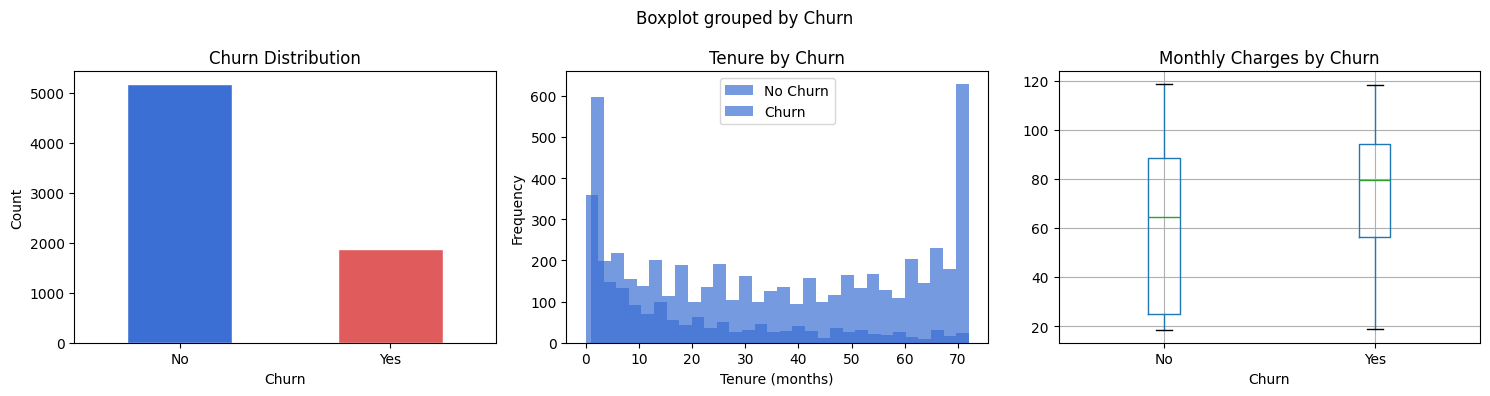

In [4]:
# ── Visualizations ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Churn Distribution
df['Churn'].value_counts().plot(
    kind='bar', ax=axes[0],
    color=['#3b6fd4', '#e05c5c'],
    edgecolor='white'
)
axes[0].set_title('Churn Distribution')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Count')
axes[0].tick_params(rotation=0)

# Tenure vs Churn
df.groupby('Churn')['tenure'].plot(
    kind='hist', ax=axes[1],
    alpha=0.7, bins=30,
    color=['#3b6fd4', '#e05c5c']
)
axes[1].set_title('Tenure by Churn')
axes[1].set_xlabel('Tenure (months)')
axes[1].legend(['No Churn', 'Churn'])

# Monthly Charges vs Churn
df.boxplot(column='MonthlyCharges', by='Churn', ax=axes[2])
axes[2].set_title('Monthly Charges by Churn')
axes[2].set_xlabel('Churn')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150)
plt.show()

In [5]:
# ── Clean Data ────────────────────────────────────────────────────

# Drop customerID (not useful)
df.drop('customerID', axis=1, inplace=True)

# Fix TotalCharges (has spaces, should be numeric)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill missing TotalCharges with median
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Encode target variable
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("Target encoded: Yes=1, No=0")
print(df['Churn'].value_counts())

Target encoded: Yes=1, No=0
Churn
0    5174
1    1869
Name: count, dtype: int64


In [6]:
# ── Define Features ───────────────────────────────────────────────

# Separate features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Identify column types
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical columns ({len(numerical_cols)}): {numerical_cols}")
print(f"\nCategorical columns ({len(categorical_cols)}): {categorical_cols}")

Numerical columns (4): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical columns (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [7]:
# ── Train Test Split ──────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # Keep same churn ratio in both splits
)

print(f"Training set:   {X_train.shape}")
print(f"Testing set:    {X_test.shape}")
print(f"\nTrain churn rate: {y_train.mean()*100:.1f}%")
print(f"Test churn rate:  {y_test.mean()*100:.1f}%")

Training set:   (5634, 19)
Testing set:    (1409, 19)

Train churn rate: 26.5%
Test churn rate:  26.5%


In [8]:
# ── Preprocessing Pipeline ────────────────────────────────────────

# Numerical: Scale features
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Categorical: One-hot encode
categorical_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

# Combine both transformers
preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer, numerical_cols),
    ('cat', categorical_transformer, categorical_cols)
])

print("Preprocessor built successfully!")
print("\nSteps:")
print("  Numerical  → StandardScaler")
print("  Categorical → OneHotEncoder")

Preprocessor built successfully!

Steps:
  Numerical  → StandardScaler
  Categorical → OneHotEncoder


In [9]:
# ── Full Pipelines (Preprocessor + Model) ────────────────────────

# Pipeline 1: Logistic Regression
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        random_state=42,
        max_iter=1000
    ))
])

# Pipeline 2: Random Forest
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ))
])

print("Pipelines built!")
print("\nLogistic Regression Pipeline:")
print(lr_pipeline)
print("\nRandom Forest Pipeline:")
print(rf_pipeline)

Pipelines built!

Logistic Regression Pipeline:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'Pho

In [10]:
# ── Train Logistic Regression (Quick Baseline) ────────────────────
print("Training Logistic Regression baseline...")
lr_pipeline.fit(X_train, y_train)
lr_base_score = lr_pipeline.score(X_test, y_test)
print(f"Baseline Accuracy: {lr_base_score:.4f}")

Training Logistic Regression baseline...
Baseline Accuracy: 0.8055


In [11]:
# ── GridSearchCV for Logistic Regression ──────────────────────────
lr_param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10],
    'classifier__solver': ['lbfgs', 'liblinear'],
    'classifier__penalty': ['l2']
}

lr_grid_search = GridSearchCV(
    lr_pipeline,
    lr_param_grid,
    cv=5,                   # 5-fold cross validation
    scoring='f1',           # Optimize for F1
    n_jobs=-1,              # Use all CPU cores
    verbose=1
)

print("Running GridSearchCV for Logistic Regression...")
lr_grid_search.fit(X_train, y_train)

print(f"\nBest Parameters: {lr_grid_search.best_params_}")
print(f"Best CV F1 Score: {lr_grid_search.best_score_:.4f}")

Running GridSearchCV for Logistic Regression...
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Best Parameters: {'classifier__C': 1, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}
Best CV F1 Score: 0.5984


In [12]:
# ── GridSearchCV for Random Forest ───────────────────────────────
rf_param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [5, 10, None],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2]
}

rf_grid_search = GridSearchCV(
    rf_pipeline,
    rf_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

print("Running GridSearchCV for Random Forest...")
rf_grid_search.fit(X_train, y_train)

print(f"\nBest Parameters: {rf_grid_search.best_params_}")
print(f"Best CV F1 Score: {rf_grid_search.best_score_:.4f}")

Running GridSearchCV for Random Forest...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best Parameters: {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}
Best CV F1 Score: 0.5716


In [13]:
# ── Get Best Models ───────────────────────────────────────────────
best_lr = lr_grid_search.best_estimator_
best_rf = rf_grid_search.best_estimator_

# ── Predictions ───────────────────────────────────────────────────
lr_preds = best_lr.predict(X_test)
rf_preds = best_rf.predict(X_test)

lr_probs = best_lr.predict_proba(X_test)[:, 1]
rf_probs = best_rf.predict_proba(X_test)[:, 1]

# ── Metrics ───────────────────────────────────────────────────────
def evaluate_model(name, y_true, y_pred, y_prob):
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"  F1 Score:  {f1_score(y_true, y_pred):.4f}")
    print(f"  ROC-AUC:   {roc_auc_score(y_true, y_prob):.4f}")
    print(f"\n  Classification Report:")
    print(classification_report(y_true, y_pred, target_names=['No Churn', 'Churn']))

evaluate_model("Logistic Regression", y_test, lr_preds, lr_probs)
evaluate_model("Random Forest",       y_test, rf_preds, rf_probs)


  Logistic Regression
  Accuracy:  0.8055
  F1 Score:  0.6040
  ROC-AUC:   0.8420

  Classification Report:
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409


  Random Forest
  Accuracy:  0.8034
  F1 Score:  0.5896
  ROC-AUC:   0.8408

  Classification Report:
              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.66      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409



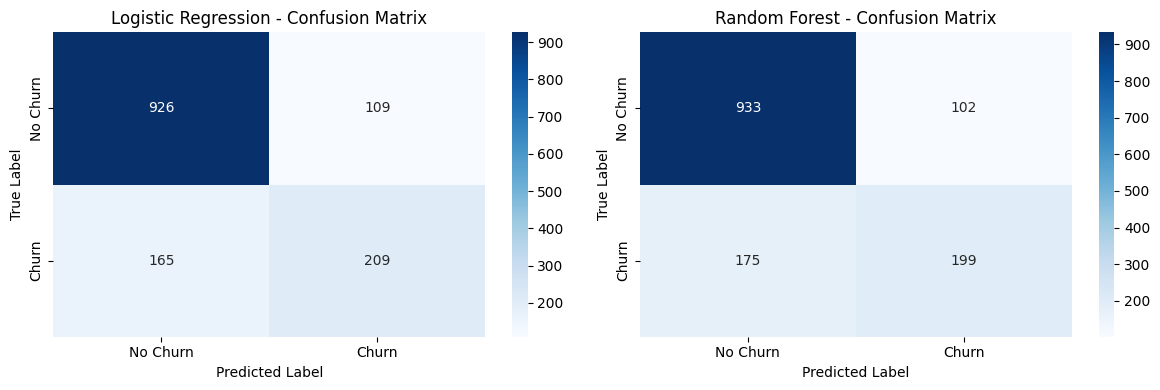

In [14]:
# ── Confusion Matrices ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, preds, title in zip(
    axes,
    [lr_preds, rf_preds],
    ['Logistic Regression', 'Random Forest']
):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(
        cm, annot=True, fmt='d',
        cmap='Blues', ax=ax,
        xticklabels=['No Churn', 'Churn'],
        yticklabels=['No Churn', 'Churn']
    )
    ax.set_title(f'{title} - Confusion Matrix')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()

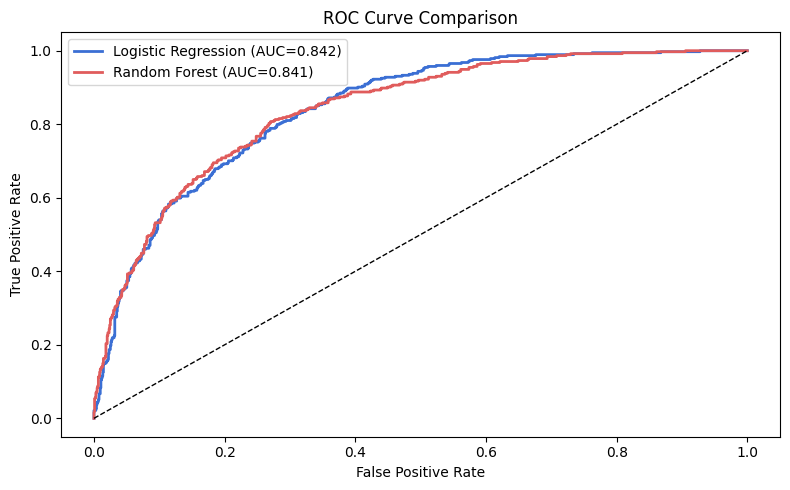

In [15]:
# ── ROC Curves ───────────────────────────────────────────────────
plt.figure(figsize=(8, 5))

for probs, label, color in zip(
    [lr_probs, rf_probs],
    ['Logistic Regression', 'Random Forest'],
    ['#3b6fd4', '#e05c5c']
):
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f'{label} (AUC={auc:.3f})', color=color, lw=2)

plt.plot([0,1], [0,1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150)
plt.show()

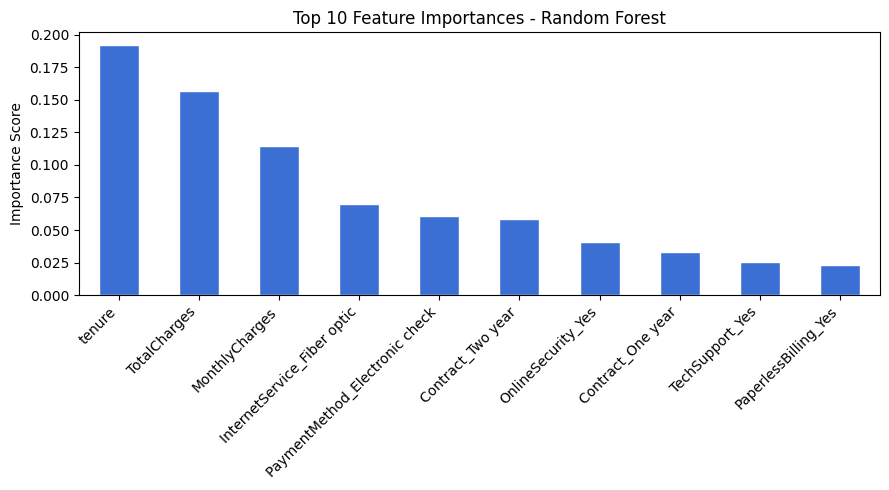

In [16]:
# ── Feature Importance (Random Forest) ───────────────────────────
rf_classifier = best_rf.named_steps['classifier']
feature_names = (
    numerical_cols +
    list(best_rf.named_steps['preprocessor']
         .transformers_[1][1]
         .named_steps['encoder']
         .get_feature_names_out(categorical_cols))
)

importances = pd.Series(
    rf_classifier.feature_importances_,
    index=feature_names
).sort_values(ascending=False)[:10]

plt.figure(figsize=(9, 5))
importances.plot(kind='bar', color='#3b6fd4', edgecolor='white')
plt.title('Top 10 Feature Importances - Random Forest')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

In [17]:
# ── Select Best Model ─────────────────────────────────────────────
lr_f1 = f1_score(y_test, lr_preds)
rf_f1 = f1_score(y_test, rf_preds)

best_model = best_rf if rf_f1 > lr_f1 else best_lr
best_name  = "Random Forest" if rf_f1 > lr_f1 else "Logistic Regression"

print(f"Best Model: {best_name}")
print(f"F1 Score:   {max(lr_f1, rf_f1):.4f}")

# ── Export Pipeline ───────────────────────────────────────────────
joblib.dump(best_model, 'churn_pipeline.pkl')
print("\nPipeline saved as 'churn_pipeline.pkl'")

# ── Verify Export ─────────────────────────────────────────────────
loaded_pipeline = joblib.load('churn_pipeline.pkl')
verify_preds = loaded_pipeline.predict(X_test)
print(f"Loaded pipeline accuracy: {accuracy_score(y_test, verify_preds):.4f}")
print("Export verified successfully!")

Best Model: Logistic Regression
F1 Score:   0.6040

Pipeline saved as 'churn_pipeline.pkl'
Loaded pipeline accuracy: 0.8055
Export verified successfully!


In [18]:
# ── Test Pipeline on New Data ─────────────────────────────────────
# Simulate a new customer
new_customer = pd.DataFrame([{
    'gender': 'Male',
    'SeniorCitizen': 0,
    'Partner': 'Yes',
    'Dependents': 'No',
    'tenure': 12,
    'PhoneService': 'Yes',
    'MultipleLines': 'No',
    'InternetService': 'Fiber optic',
    'OnlineSecurity': 'No',
    'OnlineBackup': 'No',
    'DeviceProtection': 'No',
    'TechSupport': 'No',
    'StreamingTV': 'Yes',
    'StreamingMovies': 'Yes',
    'Contract': 'Month-to-month',
    'PaperlessBilling': 'Yes',
    'PaymentMethod': 'Electronic check',
    'MonthlyCharges': 85.0,
    'TotalCharges': 1020.0
}])

prediction = loaded_pipeline.predict(new_customer)[0]
probability = loaded_pipeline.predict_proba(new_customer)[0][1]

print(f"\nNew Customer Prediction:")
print(f"  Churn: {'YES' if prediction == 1 else 'NO'}")
print(f"  Churn Probability: {probability*100:.1f}%")


New Customer Prediction:
  Churn: YES
  Churn Probability: 74.7%


In [20]:
import gradio as gr
import pandas as pd
import joblib

# Load saved pipeline
pipeline = joblib.load('churn_pipeline.pkl')

def predict_churn(gender, senior_citizen, partner, dependents, tenure,
                  phone_service, multiple_lines, internet_service,
                  online_security, online_backup, device_protection,
                  tech_support, streaming_tv, streaming_movies,
                  contract, paperless_billing, payment_method,
                  monthly_charges, total_charges):

    customer = pd.DataFrame([{
        'gender': gender,
        'SeniorCitizen': int(senior_citizen),
        'Partner': partner,
        'Dependents': dependents,
        'tenure': tenure,
        'PhoneService': phone_service,
        'MultipleLines': multiple_lines,
        'InternetService': internet_service,
        'OnlineSecurity': online_security,
        'OnlineBackup': online_backup,
        'DeviceProtection': device_protection,
        'TechSupport': tech_support,
        'StreamingTV': streaming_tv,
        'StreamingMovies': streaming_movies,
        'Contract': contract,
        'PaperlessBilling': paperless_billing,
        'PaymentMethod': payment_method,
        'MonthlyCharges': monthly_charges,
        'TotalCharges': total_charges
    }])

    prediction = pipeline.predict(customer)[0]
    probability = pipeline.predict_proba(customer)[0][1]

    label = "Will Churn" if prediction == 1 else "Will Not Churn"
    confidence = f"{probability * 100:.1f}%"

    if prediction == 1:
        risk = "High Risk" if probability > 0.7 else "Medium Risk"
    else:
        risk = "Low Risk"

    return label, confidence, risk


custom_css = """
    body, .gradio-container {
        background-color: #f0f4f8 !important;
        font-family: 'Segoe UI', sans-serif;
    }
    .main-card {
        background: #ffffff;
        border-radius: 16px;
        padding: 36px 40px;
        max-width: 960px;
        margin: 40px auto;
        box-shadow: 0 4px 24px rgba(30, 80, 160, 0.08);
        border: 1px solid #dce6f5;
    }
    .app-header {
        text-align: center;
        margin-bottom: 28px;
    }
    .app-header h1 {
        font-size: 1.9rem;
        font-weight: 700;
        color: #1a3c6e;
        margin: 0 0 6px 0;
    }
    .app-header p {
        font-size: 0.93rem;
        color: #6b7a99;
        margin: 0;
    }
    .divider {
        border: none;
        border-top: 1px solid #dce6f5;
        margin: 20px 0 28px 0;
    }
    .section-label {
        font-size: 0.78rem;
        font-weight: 700;
        color: #4a5a7a;
        text-transform: uppercase;
        letter-spacing: 0.07em;
        margin: 20px 0 10px 0;
    }
    label span {
        font-size: 0.82rem !important;
        font-weight: 600 !important;
        color: #4a5a7a !important;
    }
    input[type=number], select, .gr-input {
        background-color: #f7f9fc !important;
        border: 1.5px solid #c8d8f0 !important;
        border-radius: 8px !important;
        color: #1e2d4a !important;
    }
    .predict-btn {
        background: linear-gradient(135deg, #2157c5, #3b6fd4) !important;
        color: #ffffff !important;
        border: none !important;
        border-radius: 10px !important;
        font-size: 0.95rem !important;
        font-weight: 600 !important;
        padding: 12px 0 !important;
        width: 100%;
        margin-top: 16px;
        cursor: pointer !important;
        transition: opacity 0.2s !important;
    }
    .predict-btn:hover {
        opacity: 0.88 !important;
    }
    .result-box {
        background: #f0f5ff;
        border: 1.5px solid #c8d8f0;
        border-radius: 12px;
        padding: 24px;
        text-align: center;
        margin-top: 10px;
    }
    .app-footer {
        text-align: center;
        margin-top: 28px;
        font-size: 0.78rem;
        color: #9aa6bf;
    }
"""

with gr.Blocks(css=custom_css) as demo:
    with gr.Column(elem_classes="main-card"):

        gr.HTML("""
            <div class="app-header">
              <h1>I'M MAD</h1>
                <h1>Customer Churn Predictor</h1>
                <p>Fill in the customer details below to predict whether they are likely to churn.</p>
            </div>
            <hr class="divider"/>
        """)

        # ── Section 1: Personal Info ──────────────────────────────
        gr.HTML('<p class="section-label">Personal Information</p>')
        with gr.Row():
            gender          = gr.Dropdown(['Male', 'Female'], label="Gender", value='Male')
            senior_citizen  = gr.Dropdown([0, 1], label="Senior Citizen (1=Yes)", value=0)
            partner         = gr.Dropdown(['Yes', 'No'], label="Partner", value='Yes')
            dependents      = gr.Dropdown(['Yes', 'No'], label="Dependents", value='No')

        # ── Section 2: Account Info ───────────────────────────────
        gr.HTML('<p class="section-label">Account Information</p>')
        with gr.Row():
            tenure           = gr.Slider(0, 72, value=12, step=1, label="Tenure (months)")
            monthly_charges  = gr.Slider(0, 150, value=65.0, step=0.5, label="Monthly Charges ($)")
            total_charges    = gr.Slider(0, 9000, value=780.0, step=10, label="Total Charges ($)")

        with gr.Row():
            contract         = gr.Dropdown(['Month-to-month', 'One year', 'Two year'], label="Contract Type", value='Month-to-month')
            payment_method   = gr.Dropdown(['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)'], label="Payment Method", value='Electronic check')
            paperless_billing = gr.Dropdown(['Yes', 'No'], label="Paperless Billing", value='Yes')

        # ── Section 3: Services ───────────────────────────────────
        gr.HTML('<p class="section-label">Services</p>')
        with gr.Row():
            phone_service    = gr.Dropdown(['Yes', 'No'], label="Phone Service", value='Yes')
            multiple_lines   = gr.Dropdown(['Yes', 'No', 'No phone service'], label="Multiple Lines", value='No')
            internet_service = gr.Dropdown(['DSL', 'Fiber optic', 'No'], label="Internet Service", value='Fiber optic')

        with gr.Row():
            online_security  = gr.Dropdown(['Yes', 'No', 'No internet service'], label="Online Security", value='No')
            online_backup    = gr.Dropdown(['Yes', 'No', 'No internet service'], label="Online Backup", value='No')
            device_protection = gr.Dropdown(['Yes', 'No', 'No internet service'], label="Device Protection", value='No')

        with gr.Row():
            tech_support     = gr.Dropdown(['Yes', 'No', 'No internet service'], label="Tech Support", value='No')
            streaming_tv     = gr.Dropdown(['Yes', 'No', 'No internet service'], label="Streaming TV", value='Yes')
            streaming_movies = gr.Dropdown(['Yes', 'No', 'No internet service'], label="Streaming Movies", value='Yes')

        # ── Predict Button ────────────────────────────────────────
        predict_btn = gr.Button("Predict Churn", elem_classes="predict-btn")

        # ── Results ───────────────────────────────────────────────
        gr.HTML('<p class="section-label">Prediction Result</p>')
        with gr.Row():
            result_label      = gr.Textbox(label="Prediction", interactive=False)
            result_confidence = gr.Textbox(label="Churn Probability", interactive=False)
            result_risk       = gr.Textbox(label="Risk Level", interactive=False)

        gr.HTML("""
            <div class="app-footer">
                Random Forest Pipeline &nbsp;·&nbsp; Trained on Telco Churn Dataset &nbsp;·&nbsp; Exported with Joblib
            </div>
        """)

    # ── Event ─────────────────────────────────────────────────────
    predict_btn.click(
        fn=predict_churn,
        inputs=[
            gender, senior_citizen, partner, dependents, tenure,
            phone_service, multiple_lines, internet_service,
            online_security, online_backup, device_protection,
            tech_support, streaming_tv, streaming_movies,
            contract, paperless_billing, payment_method,
            monthly_charges, total_charges
        ],
        outputs=[result_label, result_confidence, result_risk]
    )

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0dc15a83dd133fff8b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
